In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data_filename = '/content/drive/MyDrive/Machine Learning/KNN/Lab_Exercise/german.data-numeric'
data_array = np.genfromtxt(data_filename)
df = pd.DataFrame(data_array, columns=['A' + str(i) for i in range(1, 25)] +  ['label'])
df['label'] = df['label'].replace(2, 0)
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A16,A17,A18,A19,A20,A21,A22,A23,A24,label
0,1.0,6.0,4.0,12.0,5.0,5.0,3.0,4.0,1.0,67.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,2.0,48.0,2.0,60.0,1.0,3.0,2.0,2.0,1.0,22.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,4.0,12.0,4.0,21.0,1.0,4.0,3.0,3.0,1.0,49.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
3,1.0,42.0,2.0,79.0,1.0,4.0,3.0,4.0,2.0,45.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,1.0,24.0,3.0,49.0,1.0,3.0,3.0,4.0,4.0,53.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# Preprocessing

In [9]:
X = df.drop(['label'], axis=1)
# X = (X - X.mean()) / X.sdt()
X = (X - X.min()) / (X.max() - X.min())
X.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A15,A16,A17,A18,A19,A20,A21,A22,A23,A24
0,0.000000,0.029412,1.00,0.054945,1.0,1.00,0.666667,1.000000,0.000000,0.857143,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.333333,0.647059,0.50,0.318681,0.0,0.50,0.333333,0.333333,0.000000,0.053571,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,1.000000,0.117647,1.00,0.104396,0.0,0.75,0.666667,0.666667,0.000000,0.535714,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.000000,0.558824,0.50,0.423077,0.0,0.75,0.666667,1.000000,0.333333,0.464286,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.000000,0.294118,0.75,0.258242,0.0,0.50,0.666667,1.000000,1.000000,0.607143,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, df['label'], test_size=0.2, random_state=42)

In [46]:
def visualize_optimal(scores, k_values, metric):
  plt.figure(figsize=(12, 8))
  plt.plot(k_values, scores, marker='o')
  plt.title(metric)
  plt.xlabel('Numbers of neighbors')
  plt.ylabel('Values')
  plt.xticks(k_values)
  plt.grid()
  plt.show()

In [35]:
def optimal_method(X_train, y_train, X_test, y_test, k_values):
  metrics = ['minkowski', 'manhattan', 'euclidean']
  results = {}
  for metric in metrics:
    errors = []
    for k in k_values:
      knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights='distance')
      knn.fit(X_train, y_train)
      y_pred = knn.predict(X_test)
      error = mean_squared_error(y_test, y_pred)
      errors.append(error)
    k = k_values[np.argmin(errors)]
    results[metric] = (k, np.min(errors))
    visualize_optimal(errors, k_values, metric)
  print(results)

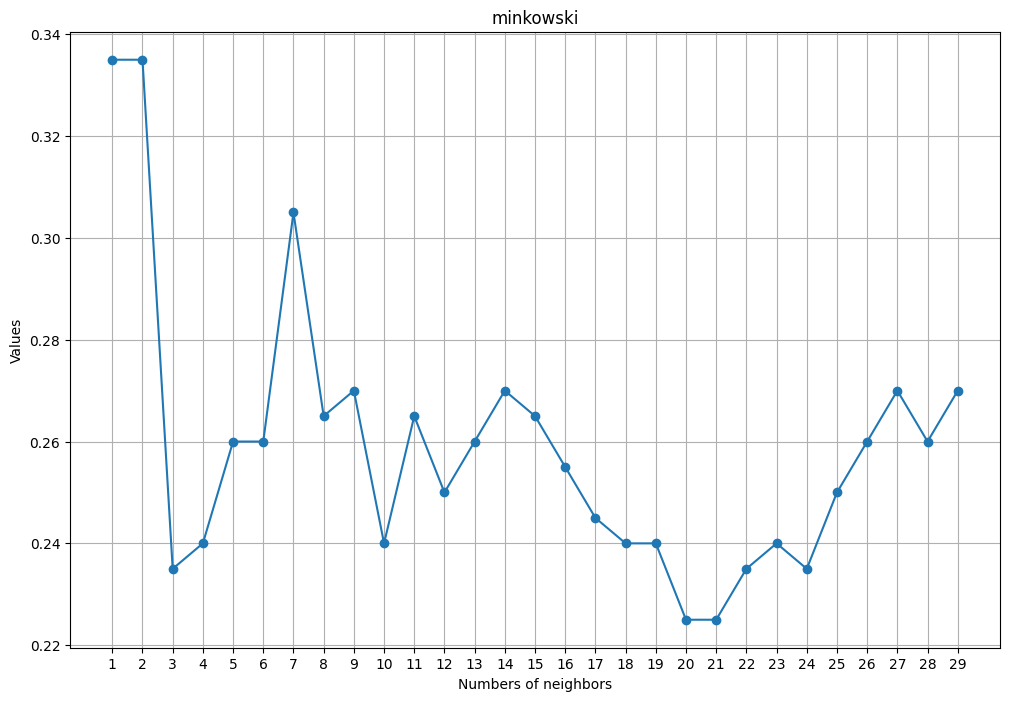

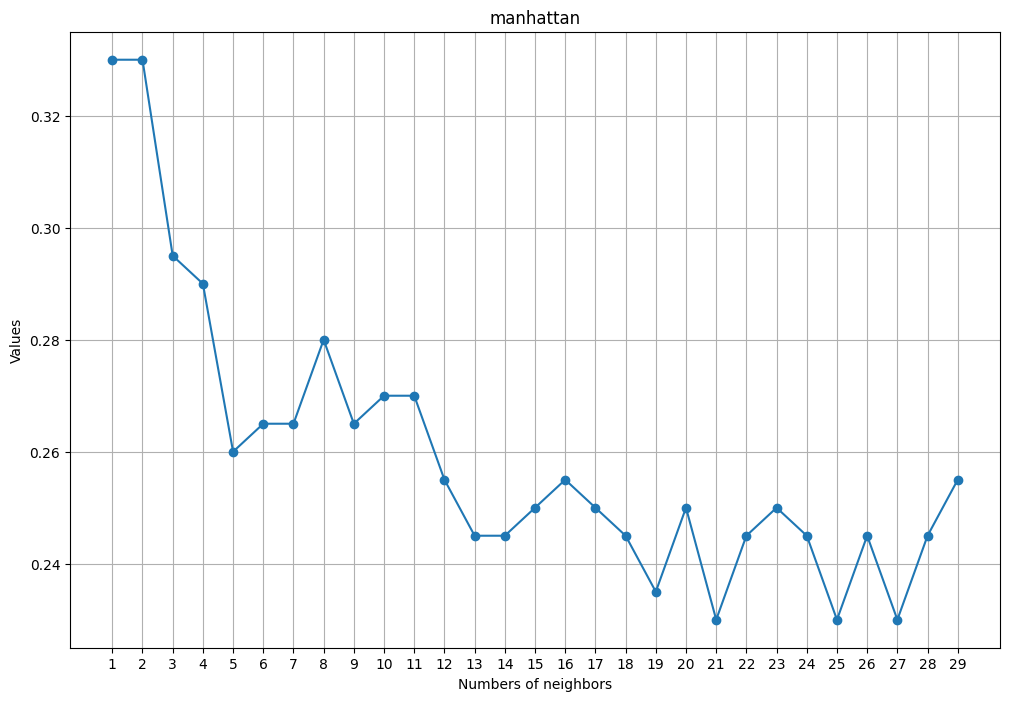

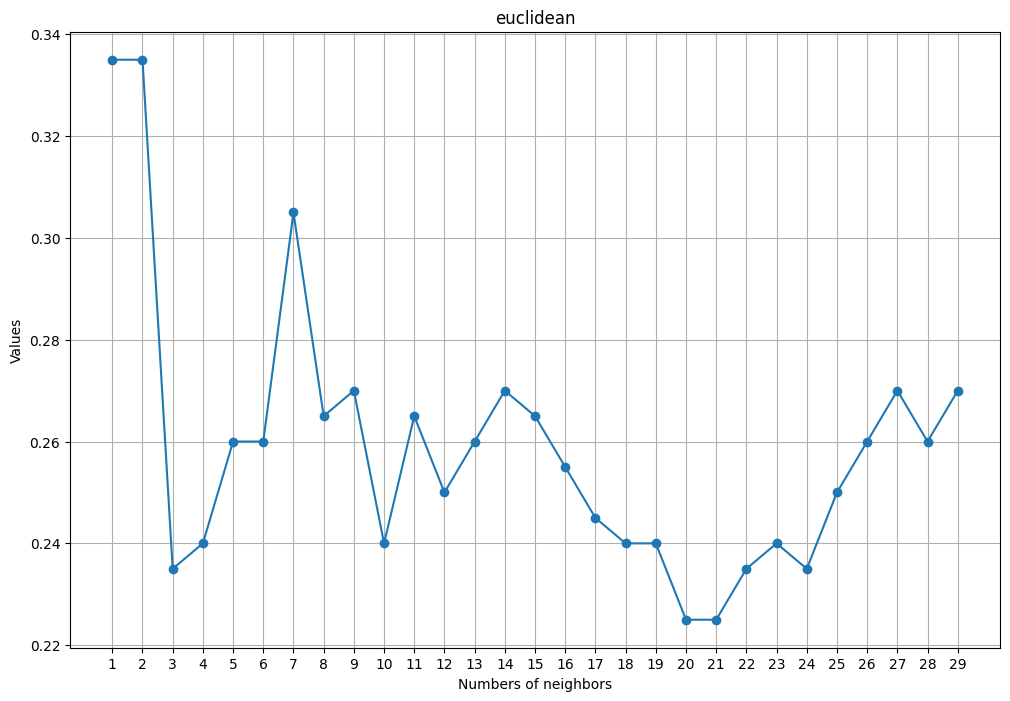

{'minkowski': (20, 0.225), 'manhattan': (21, 0.23), 'euclidean': (20, 0.225)}


In [43]:
k_values = range(1,30)
optimal_method(X_train, y_train, X_test, y_test, k_values)

In [53]:
optimal_k = 20
optimal_metric = 'euclidean'

knn = KNeighborsClassifier(n_neighbors=optimal_k, metric=optimal_metric, weights='distance')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
accurancy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f'Accurancy: {accurancy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')

Accurancy: 0.775
Precision: 0.7891566265060241
Recall: 0.9290780141843972
